Prerna Ladkani       
roll no :37

In [ ]:
pip install --upgrade tensorflow


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Conv2D, MaxPooling2D, ZeroPadding2D, GlobalAveragePooling2D
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [ ]:

(x_train, y_train), (x_test, y_test) = mnist.load_data()



In [ ]:
y_test

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [ ]:

x_train_rgb = np.zeros((x_train.shape[0], 28, 28, 3))
x_test_rgb = np.zeros((x_test.shape[0], 28, 28, 3))

for i in range(3):
    x_train_rgb[:, :, :, i] = x_train / 255.0
    x_test_rgb[:, :, :, i] = x_test / 255.0



In [ ]:

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


y_train shape: (60000, 10)
y_test shape: (10000, 10)


In [ ]:

input_shape = (28, 28, 3)

model = Sequential()
model.add(Conv2D(32, (5, 5), activation='relu', input_shape=input_shape))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))


model.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)                   │ (None, 24, 24, 32)          │           2,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 12, 12, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_19 (Conv2D)                   │ (None, 10, 10, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_20 (Conv2D)                   │ (None, 3, 3, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_6 (Flatten)                  │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 128)                 │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 243,658 (951.79 KB)

 Trainable params: 243,658 (951.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer=Adam(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])



In [ ]:
history = model.fit(x_train_rgb, y_train, epochs=10, batch_size=64, validation_data=(x_test_rgb, y_test))


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 92s 95ms/step - accuracy: 0.9035 - loss: 0.3208 - val_accuracy: 0.9877 - val_loss: 0.0400
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 71s 76ms/step - accuracy: 0.9865 - loss: 0.0405 - val_accuracy: 0.9893 - val_loss: 0.0339
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 74s 79ms/step - accuracy: 0.9907 - loss: 0.0308 - val_accuracy: 0.9874 - val_loss: 0.0445
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 78s 75ms/step - accuracy: 0.9938 - loss: 0.0204 - val_accuracy: 0.9896 - val_loss: 0.0361
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 70s 74ms/step - accuracy: 0.9950 - loss: 0.0168 - val_accuracy: 0.9850 - val_loss: 0.0483
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 70s 74ms/step - accuracy: 0.9952 - loss: 0.0148 - val_accuracy: 0.9895 - val_loss: 0.0387
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 75ms/step - accuracy: 0.9962 - loss: 0.0118 - val_accuracy: 0.9919 - val_loss: 0.0325
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 71s 75ms/step - accuracy: 0.9973 - loss: 0.0102 - 

In [ ]:

test_loss, test_acc = model.evaluate(x_test_rgb, y_test)
print(f"Test accuracy: {test_acc:.4f}")



313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9896 - loss: 0.0415
Test accuracy: 0.9922


In [ ]:
class_colors = [
    'blue', 'green', 'red', 'cyan', 'magenta',
    'yellow', 'black', 'orange', 'pink', 'purple'
]



In [ ]:
def plot_colored_predictions(images, labels, predicted_labels, colors, samples=3, img_size=(12, 4), title_size=12):
    plt.figure(figsize=img_size)
    for i in range(samples):
        plt.subplot(1, samples, i + 1)
        plt.imshow(images[i])
        plt.gca().add_patch(plt.Rectangle((0, 0), 28, 28, color=colors[np.argmax(predicted_labels[i])], alpha=0.3))
        plt.title(f"Predicted: {np.argmax(predicted_labels[i])}\nActual: {np.argmax(labels[i])}", fontsize=title_size)
        plt.axis('off')
    plt.show()




In [ ]:
predicted_labels = model.predict(x_test_rgb)


313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step


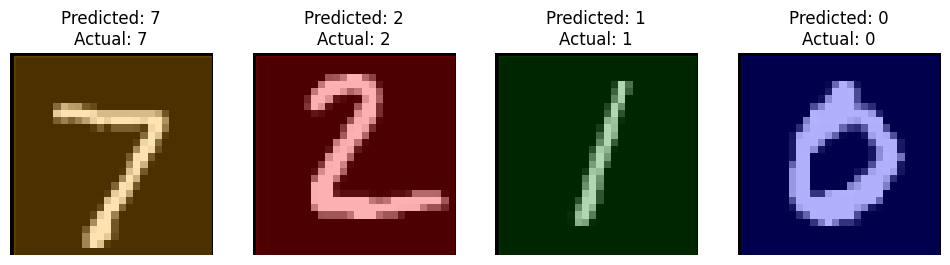

In [ ]:
plot_colored_predictions(x_test_rgb, y_test, predicted_labels, class_colors, samples=4)
